# [MountainCar-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car/)

Un auto está atrapado entre dos montañas y **no tiene suficiente potencia para subir directamente**.  
Debe **balancearse hacia atrás y adelante** hasta ganar el impulso necesario para alcanzar la cima derecha.

---

### Estado (`state`)
Un vector de **2 valores continuos**:
1. **Posición del carro**  →  en el rango `[-1.2, 0.6]`
2. **Velocidad del carro** →  en el rango `[-0.07, 0.07]`

Cada observación del entorno entrega un vector `[posición, velocidad]`.

---

### Acciones (`action`)
El agente puede ejecutar **3 acciones discretas**:
- `0` → empujar hacia la **izquierda**
- `1` → **no empujar** (sin fuerza)
- `2` → empujar hacia la **derecha**

---

### Recompensa (`reward`)
- `-1` por cada paso → penaliza tardarse en llegar  
- El episodio termina cuando `posición ≥ 0.5` (el carro alcanza la cima)

---

> **Objetivo:**  
> Entrenar un agente que aprenda, a través de *Q-Learning*, la secuencia de movimientos que le permite **acumular impulso y llegar a la meta en el menor número de pasos posible.**


In [16]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random

# Crear el entorno MountainCar
env = gym.make("MountainCar-v0", render_mode="rgb_array")

# Inspeccionar espacio de observaciones y acciones
print("Espacio de observaciones:", env.observation_space)
print("Espacio de acciones:", env.action_space)

Espacio de observaciones: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Espacio de acciones: Discrete(3)


In [17]:
# Ejemplo de observaciones y acciones posibles
state, _ = env.reset()
print(f"Ejemplo de estado inicial: {state}")
print(f"Rango de posición: {env.observation_space.low[0]} a {env.observation_space.high[0]}")
print(f"Rango de velocidad: {env.observation_space.low[1]} a {env.observation_space.high[1]}")
print(f"Número de acciones posibles: {env.action_space.n}")
print("Acciones: 0 = izquierda, 1 = neutro, 2 = derecha")

Ejemplo de estado inicial: [-0.5702742  0.       ]
Rango de posición: -1.2000000476837158 a 0.6000000238418579
Rango de velocidad: -0.07000000029802322 a 0.07000000029802322
Número de acciones posibles: 3
Acciones: 0 = izquierda, 1 = neutro, 2 = derecha


In [18]:
# ==========================================
# Discretización del espacio de estados
# ==========================================
# En MountainCar el espacio de estados es continuo (posición, velocidad)
# Así que debemos discretizarlo en una cuadrícula para usar Q-learning.

n_bins = (20, 20)   # número de divisiones por dimensión (posición, velocidad)
obs_low = env.observation_space.low
obs_high = env.observation_space.high

# Crear los intervalos de discretización
bins = [np.linspace(obs_low[i], obs_high[i], n_bins[i]) for i in range(len(n_bins))]

def discretize_state(state):
    """Convierte un estado continuo en índices discretos"""
    pos, vel = state
    d_pos = np.digitize(pos, bins[0]) - 1
    d_vel = np.digitize(vel, bins[1]) - 1
    return (d_pos, d_vel)

# Crear la Q-table inicial
Q = np.zeros(n_bins + (env.action_space.n,))
print("Tamaño de la Q-table:", Q.shape)


Tamaño de la Q-table: (20, 20, 3)


Divisiones de posición (bins):
[-1.2   -1.105 -1.011 -0.916 -0.821 -0.726 -0.632 -0.537 -0.442 -0.347
 -0.253 -0.158 -0.063  0.032  0.126  0.221  0.316  0.411  0.505  0.6  ]

Divisiones de velocidad (bins):
[-0.07  -0.063 -0.055 -0.048 -0.041 -0.033 -0.026 -0.018 -0.011 -0.004
  0.004  0.011  0.018  0.026  0.033  0.041  0.048  0.055  0.063  0.07 ]


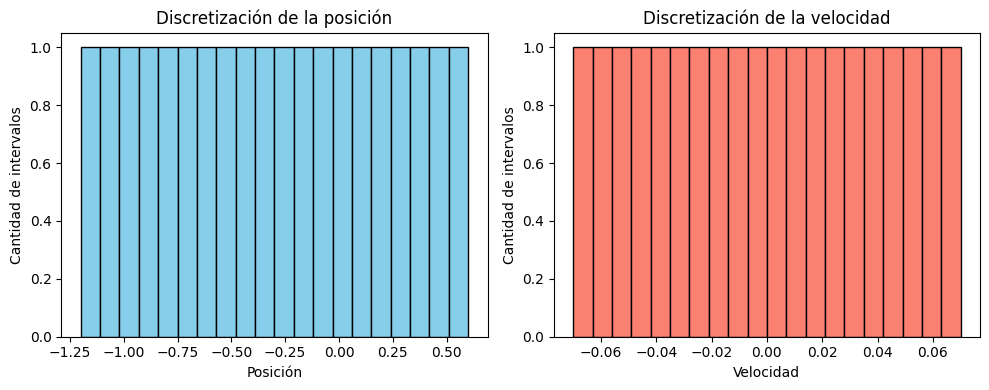

In [19]:
# ==========================================
# Visualización de la discretización
# ==========================================
pos_bins = bins[0]
vel_bins = bins[1]

print("Divisiones de posición (bins):")
print(np.round(pos_bins, 3))
print("\nDivisiones de velocidad (bins):")
print(np.round(vel_bins, 3))

# Visualización con matplotlib
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# --- Gráfico 1: Distribución de bins de posición ---
ax[0].hist(pos_bins, bins=len(pos_bins), color='skyblue', edgecolor='black')
ax[0].set_title("Discretización de la posición")
ax[0].set_xlabel("Posición")
ax[0].set_ylabel("Cantidad de intervalos")

# --- Gráfico 2: Distribución de bins de velocidad ---
ax[1].hist(vel_bins, bins=len(vel_bins), color='salmon', edgecolor='black')
ax[1].set_title("Discretización de la velocidad")
ax[1].set_xlabel("Velocidad")
ax[1].set_ylabel("Cantidad de intervalos")

plt.tight_layout()
plt.show()


In [20]:
# ==========================================
# Parámetros de aprendizaje
# ==========================================
alpha = 0.1      # tasa de aprendizaje
gamma = 0.99     # descuento
epsilon = 1.0    # probabilidad inicial de exploración
epsilon_decay = 0.995
epsilon_min = 0.05
episodes = 5000  # número de episodios

rewards_per_episode = []


## Visualización del entorno MountainCar-v0

Visualización inicial del entorno MountainCar-v0 completada 🚗⛰️


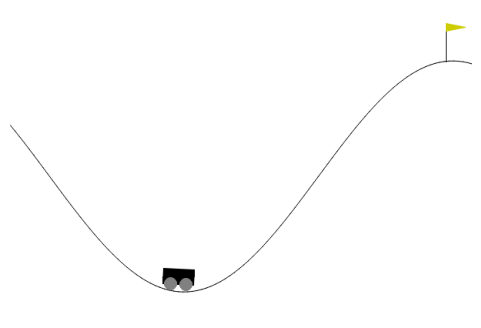

In [ ]:
# ==========================================
# Visualización del entorno MountainCar-v0
# ==========================================
import matplotlib.pyplot as plt
from IPython import display
import time

env_vis = gym.make("MountainCar-v0", render_mode="rgb_array")

state, _ = env_vis.reset()
frames = []

for step in range(20):  # capturar algunos frames iniciales
    # Política aleatoria (solo para ver movimiento)
    action = env_vis.action_space.sample()
    next_state, reward, terminated, truncated, _ = env_vis.step(action)
    frames.append(env_vis.render())  # guardar frame actual
    if terminated or truncated:
        break

env_vis.close()

# Mostrar los frames capturados como animación
plt.figure(figsize=(6,4))
for frame in frames:
    plt.imshow(frame)
    plt.axis("off")
    display.display(plt.gcf())
    display.clear_output(wait=True)
    time.sleep(0.05)

print("Visualización inicial del entorno MountainCar-v0 completada 🚗⛰️")


In [ ]:
# ==========================================
# Entrenamiento del agente
# ==========================================

for ep in range(episodes):
    state, _ = env.reset()
    state_disc = discretize_state(state)
    done = False
    total_reward = 0

    while not done:
        # -----------------------------
        # TODO 1: Política ε-greedy
        # Si random < epsilon → acción aleatoria
        # Si no → acción con mayor valor Q
        # -----------------------------
        # action = ...

        # Ejecutar acción en el entorno
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward
        next_state_disc = discretize_state(next_state)

        # -----------------------------
        # TODO 2: Actualizar la Q-table usando la ecuación de Bellman
        # Q[s,a] ← Q[s,a] + α [r + γ max_a' Q[s',a'] − Q[s,a]]
        # -----------------------------

        # Actualizar el estado
        state_disc = next_state_disc

    # Guardar la recompensa total del episodio
    rewards_per_episode.append(total_reward)

    # Decaimiento de epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # Mostrar progreso cada cierto número de episodios
    if (ep + 1) % 200 == 0:
        avg_reward = np.mean(rewards_per_episode[-100:])
        print(f"Episodio {ep+1}/{episodes} | Recompensa promedio: {avg_reward:.2f}")

env.close()


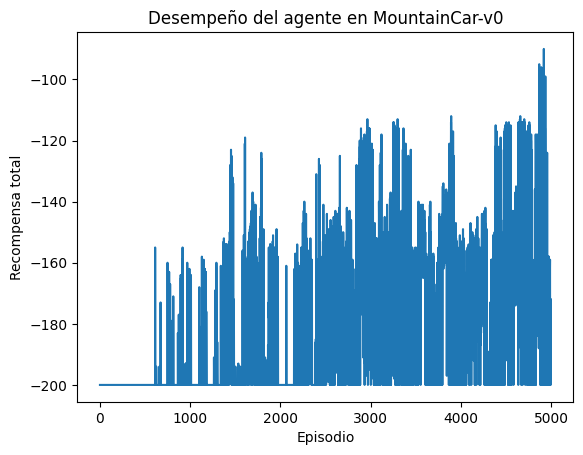

In [22]:
# ==========================================
# Visualización del desempeño
# ==========================================
plt.plot(rewards_per_episode)
plt.xlabel("Episodio")
plt.ylabel("Recompensa total")
plt.title("Desempeño del agente en MountainCar-v0")
plt.show()


In [23]:
# ==========================================
# Prueba del agente entrenado
# ==========================================
env = gym.make("MountainCar-v0", render_mode="human")
state, _ = env.reset()
state_disc = discretize_state(state)
done = False

while not done:
    action = np.argmax(Q[state_disc])  # acción óptima
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    state_disc = discretize_state(next_state)

env.close()
